# Medicare Opioid Prescribing vs. Overdose Deaths: Analysis

**Questions**
1. How has opioid prescribing in Medicare Part D changed since 2013, and how does that compare with overdose deaths?
2. Across states, does heavier prescribing still go with more overdose deaths?
3. Which prescriber groups write the opioid prescriptions, and how is that shifting?
4. How many prescribers are extreme outliers compared with peers in their own specialty, and is it persistent?

**Data:** real public data. CMS Medicare Part D Prescribers (2019-2024, 7.8M prescriber-years), CMS opioid prescribing
rates by geography (2013-2024), CDC provisional overdose deaths (2015-2024), US Census population.
Everything is read from the `analytics` views in PostgreSQL (built by `02_load_postgres.py`).

In [1]:
import importlib
import numpy as np
import pandas as pd
import psycopg
import matplotlib.pyplot as plt
import viz_style as vs

vs.apply()
CONNINFO = importlib.import_module("02_load_postgres").CONNINFO


def sql(query):
    with psycopg.connect(CONNINFO) as conn, conn.cursor() as cur:
        cur.execute(query)
        df = pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])
    # PostgreSQL numerics arrive as Decimal; convert to float for analysis
    for c in df.columns:
        if df[c].dtype == object and len(df) and df[c].map(type).astype(str).str.contains("Decimal").any():
            df[c] = df[c].astype(float)
    return df


national = sql("SELECT * FROM analytics.national_trend ORDER BY year")
state_year = sql("SELECT * FROM analytics.state_year")
states = sql("SELECT * FROM analytics.state_prescribing_vs_deaths")
specialty = sql("SELECT * FROM analytics.specialty_year")
rural = sql("SELECT * FROM analytics.rural_urban_trend ORDER BY year")
national.tail(3)

,year,prescribers,opioid_prescribers,opioid_claims,total_claims,opioid_rate,la_opioid_rate,opioid_rate_index_2013,all_drug_deaths,opioid_deaths,synthetic_opioid_deaths,rx_opioid_deaths,heroin_deaths,synthetic_share_pct
9,2022,1330828,788440,59779008.0,1.541470e+09,3.88,9.37,66.7,109413.0,82851.0,74829.0,11934.0,5958.0,90.3
10,2023,1379131,796960,59311234.0,1.614516e+09,3.67,8.88,63.1,106881.0,80719.0,74091.0,10180.0,4062.0,91.8
11,2024,1415649,808192,60244349.0,1.709091e+09,3.52,8.44,60.5,80860.0,55007.0,48662.0,8034.0,2794.0,88.5


## 1. Prescribing fell for 11 straight years while overdose deaths doubled

D:\Projects\Medicare_Opioid_Prescribing\Python\viz_style.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


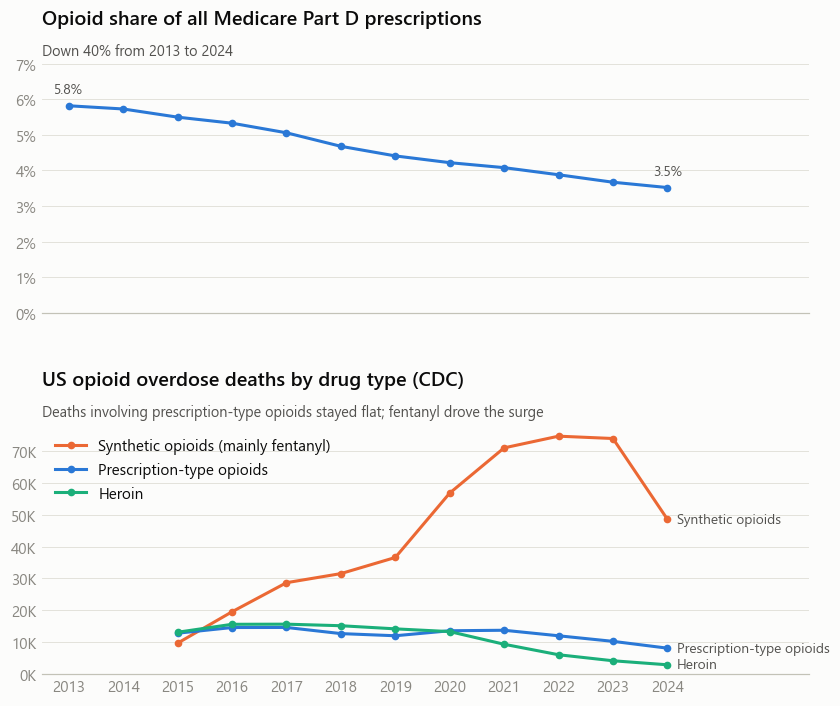

,year,opioid_rate,opioid_rate_index_2013,all_drug_deaths,opioid_deaths,synthetic_opioid_deaths,rx_opioid_deaths,synthetic_share_pct
0,2013,5.82,100.0,NaN,NaN,NaN,NaN,NaN
1,2014,5.73,98.5,NaN,NaN,NaN,NaN,NaN
2,2015,5.50,94.5,52623.0,33203.0,9610.0,12747.0,28.9
3,2016,5.33,91.6,63938.0,42435.0,19500.0,14534.0,46.0
4,2017,5.06,86.9,70699.0,47885.0,28659.0,14559.0,59.8
5,2018,4.68,80.4,67850.0,47096.0,31525.0,12620.0,66.9
6,2019,4.41,75.8,71130.0,50178.0,36603.0,11941.0,72.9
7,2020,4.22,72.5,92478.0,69061.0,56894.0,13518.0,82.4
8,2021,4.08,70.1,107573.0,80997.0,71143.0,13674.0,87.8
9,2022,3.88,66.7,109413.0,82851.0,74829.0,11934.0,90.3


In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7.2), sharex=True, gridspec_kw={"hspace": 0.45})

ax1.plot(national["year"], national["opioid_rate"] / 100, color=vs.BLUE, marker="o", markersize=4)
for y in (2013, 2024):
    v = national.loc[national["year"] == y, "opioid_rate"].iat[0] / 100
    ax1.annotate(f"{v:.1%}", (y, v), textcoords="offset points", xytext=(0, 8), ha="center", color=vs.INK_2, fontsize=9)
ax1.set_ylim(0, 0.07)
vs.pct(ax1, decimals=0)
ax1.set_title("Opioid share of all Medicare Part D prescriptions")
drop = 1 - national["opioid_rate"].iat[-1] / national["opioid_rate"].iat[0]
vs.subtitle(ax1, f"Down {drop:.0%} from 2013 to 2024")

deaths = national.dropna(subset=["opioid_deaths"])
for col, label, color in [("synthetic_opioid_deaths", "Synthetic opioids (mainly fentanyl)", vs.ORANGE),
                          ("rx_opioid_deaths", "Prescription-type opioids", vs.BLUE),
                          ("heroin_deaths", "Heroin", vs.AQUA)]:
    ax2.plot(deaths["year"], deaths[col], color=color, label=label, marker="o", markersize=4)
    ax2.annotate(label.split(" (")[0], (deaths["year"].iat[-1], deaths[col].iat[-1]), textcoords="offset points",
                 xytext=(6, 0), va="center", color=vs.INK_2, fontsize=9)
ax2.set_ylim(0, None)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))
ax2.set_title("US opioid overdose deaths by drug type (CDC)")
vs.subtitle(ax2, "Deaths involving prescription-type opioids stayed flat; fentanyl drove the surge")
ax2.legend(loc="upper left")
ax2.set_xlim(2012.5, 2026.6)
ax2.set_xticks(range(2013, 2025))
vs.save(fig, "01_prescribing_vs_deaths")
plt.show()
national[["year", "opioid_rate", "opioid_rate_index_2013", "all_drug_deaths", "opioid_deaths",
          "synthetic_opioid_deaths", "rx_opioid_deaths", "synthetic_share_pct"]]

## 2. Across states, prescribing no longer predicts overdose deaths

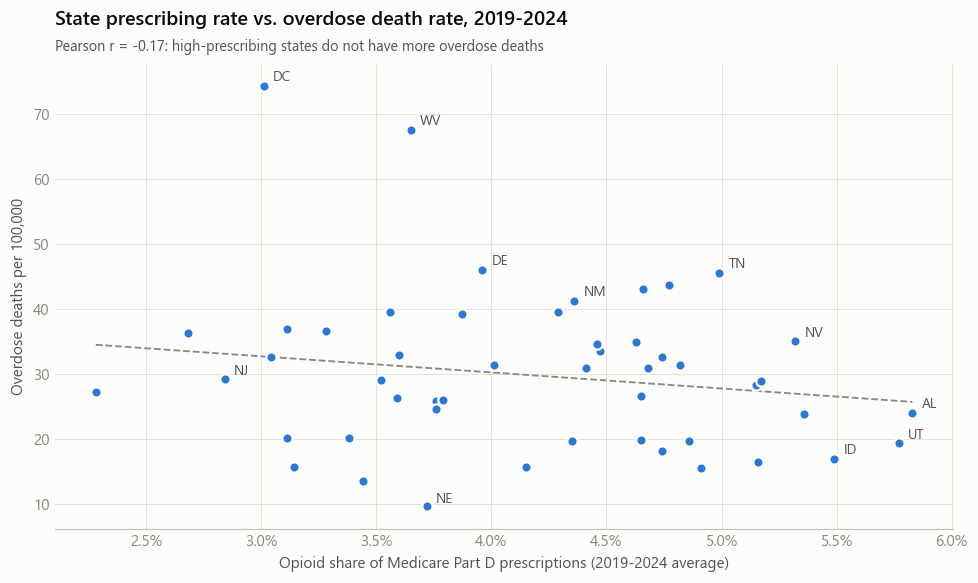

,r_all_overdose,r_rx_opioid,r_synthetic
year,,,
2015,0.03,0.34,-0.37
2016,-0.19,0.27,-0.46
2017,-0.24,0.24,-0.56
2018,-0.24,0.27,-0.50
2019,-0.28,0.27,-0.48
2020,-0.22,0.14,-0.38
2021,-0.16,0.27,-0.32
2022,-0.17,0.11,-0.35
2023,-0.14,0.14,-0.25


In [3]:
x, y = states["avg_opioid_rate"] / 100, states["avg_overdose_death_rate"]
r = np.corrcoef(x, y)[0, 1]
slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(9, 5.4))
ax.scatter(x, y, s=46, color=vs.BLUE, edgecolor=vs.SURFACE, linewidth=1.5, zorder=3)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, slope * xs + intercept, color=vs.MUTED, linewidth=1.2, linestyle="--", zorder=2)
label = {"WV", "DC", "AL", "UT", "NV", "NE", "TN", "DE", "NJ", "ID", "NM"}
for _, row in states.iterrows():
    if row["state_abbr"] in label:
        ax.annotate(row["state_abbr"], (row["avg_opioid_rate"] / 100, row["avg_overdose_death_rate"]),
                    textcoords="offset points", xytext=(6, 3), fontsize=9, color=vs.INK_2)
vs.pct(ax, "x", decimals=1)
ax.set_xlabel("Opioid share of Medicare Part D prescriptions (2019-2024 average)")
ax.set_ylabel("Overdose deaths per 100,000")
ax.grid(axis="x", visible=True)
ax.set_title("State prescribing rate vs. overdose death rate, 2019-2024")
vs.subtitle(ax, f"Pearson r = {r:.2f}: high-prescribing states do not have more overdose deaths")
vs.save(fig, "02_state_scatter")
plt.show()

corr = state_year[state_year["year"].between(2015, 2024)].groupby("year").apply(
    lambda d: pd.Series({
        "r_all_overdose": d["opioid_rate"].corr(d["overdose_death_rate"]),
        "r_rx_opioid": d["opioid_rate"].corr(d["rx_opioid_death_rate"]),
        "r_synthetic": d["opioid_rate"].corr(d["synthetic_death_rate"]),
    }), include_groups=False).round(2)
corr

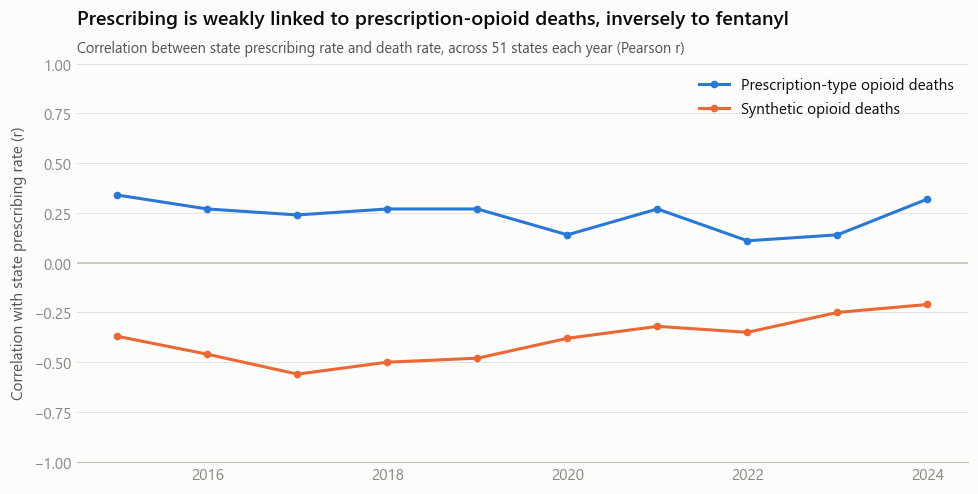

In [4]:
fig, ax = plt.subplots()
for col, label, color in [("r_rx_opioid", "Prescription-type opioid deaths", vs.BLUE),
                          ("r_synthetic", "Synthetic opioid deaths", vs.ORANGE)]:
    ax.plot(corr.index, corr[col], color=color, marker="o", markersize=4, label=label)
ax.axhline(0, color=vs.NEUTRAL, linewidth=1)
ax.set_ylim(-1, 1)
ax.set_ylabel("Correlation with state prescribing rate (r)")
ax.set_title("Prescribing is weakly linked to prescription-opioid deaths, inversely to fentanyl")
vs.subtitle(ax, "Correlation between state prescribing rate and death rate, across 51 states each year (Pearson r)")
ax.legend(loc="upper right")
vs.save(fig, "03_correlation_by_year")
plt.show()

## 3. Who prescribes: nurse practitioners and PAs are taking over from primary care physicians

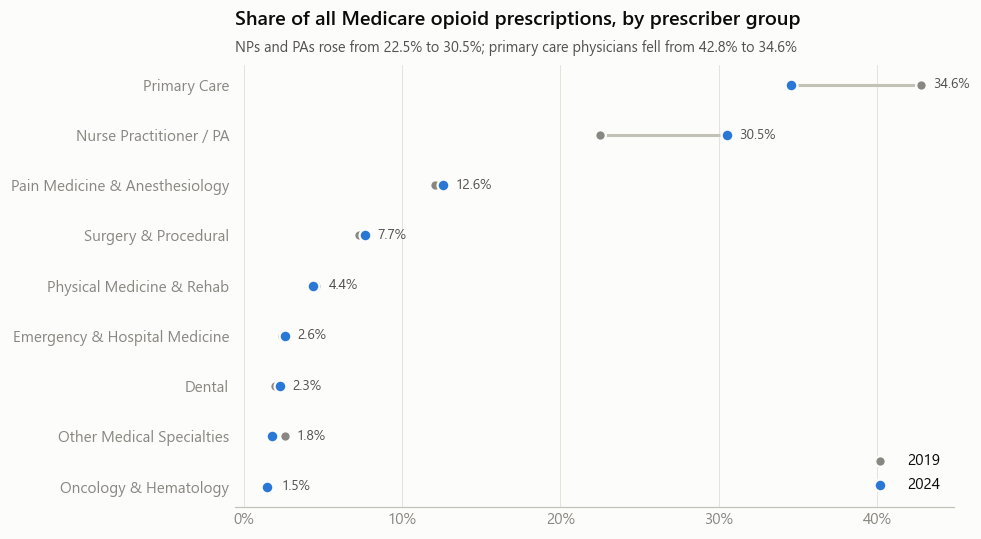

,specialty_group,prescribers,opioid_claims,opioid_rate,share_of_all_opioid_claims,la_opioid_rate,avg_days_per_opioid_claim
74,Primary Care,264219,20425227.0,2.51,34.6,5.93,22.5
68,Nurse Practitioner / PA,421653,17970784.0,4.04,30.5,9.71,20.7
72,Pain Medicine & Anesthesiology,10919,7452282.0,52.12,12.6,14.91,27.5
77,Surgery & Procedural,136848,4524120.0,9.63,7.7,0.65,7.4
73,Physical Medicine & Rehab,11673,2600026.0,28.62,4.4,14.01,25.4
66,Emergency & Hospital Medicine,78595,1556713.0,5.47,2.6,1.94,7.7
65,Dental,138942,1360949.0,9.17,2.3,0.02,3.0
71,Other Medical Specialties,154783,1049663.0,0.49,1.8,4.27,22.7
69,Oncology & Hematology,20869,894535.0,6.78,1.5,14.64,19.4
75,"Psychiatry, Neurology & Addiction",58685,556049.0,0.93,0.9,14.88,26.6


In [5]:
s19 = specialty[specialty["year"] == 2019].set_index("specialty_group")["share_of_all_opioid_claims"]
s24 = specialty[specialty["year"] == 2024].set_index("specialty_group")["share_of_all_opioid_claims"]
dumb = pd.DataFrame({"2019": s19, "2024": s24}).dropna().sort_values("2024")
dumb = dumb[dumb["2024"] >= 1]

fig, ax = plt.subplots(figsize=(9, 5))
yy = range(len(dumb))
ax.hlines(yy, dumb["2019"], dumb["2024"], color=vs.NEUTRAL, linewidth=2, zorder=1)
ax.scatter(dumb["2019"], yy, color=vs.MUTED, s=48, zorder=2, label="2019", edgecolor=vs.SURFACE, linewidth=1.5)
ax.scatter(dumb["2024"], yy, color=vs.BLUE, s=60, zorder=3, label="2024", edgecolor=vs.SURFACE, linewidth=1.5)
for i, (name, row) in enumerate(dumb.iterrows()):
    ax.annotate(f"{row['2024']:.1f}%", (max(row["2019"], row["2024"]), i), textcoords="offset points",
                xytext=(8, 0), va="center", fontsize=9, color=vs.INK_2)
ax.set_yticks(list(yy), dumb.index)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Share of all Medicare opioid prescriptions, by prescriber group")
vs.subtitle(ax, "NPs and PAs rose from 22.5% to 30.5%; primary care physicians fell from 42.8% to 34.6%")
ax.legend(loc="lower right")
vs.save(fig, "04_specialty_shift")
plt.show()
specialty[specialty["year"] == 2024].sort_values("share_of_all_opioid_claims", ascending=False)[
    ["specialty_group", "prescribers", "opioid_claims", "opioid_rate", "share_of_all_opioid_claims",
     "la_opioid_rate", "avg_days_per_opioid_claim"]]

Pain medicine is a separate story: about 11,000 prescribers (under 1% of the total) write 12.6% of all opioid
claims, and opioids make up about half of everything they prescribe. That is expected for the specialty, which is why the
outlier analysis below compares each prescriber only with peers in the **same specialty**.

## 4. Peer outliers: who prescribes far more than their own specialty?

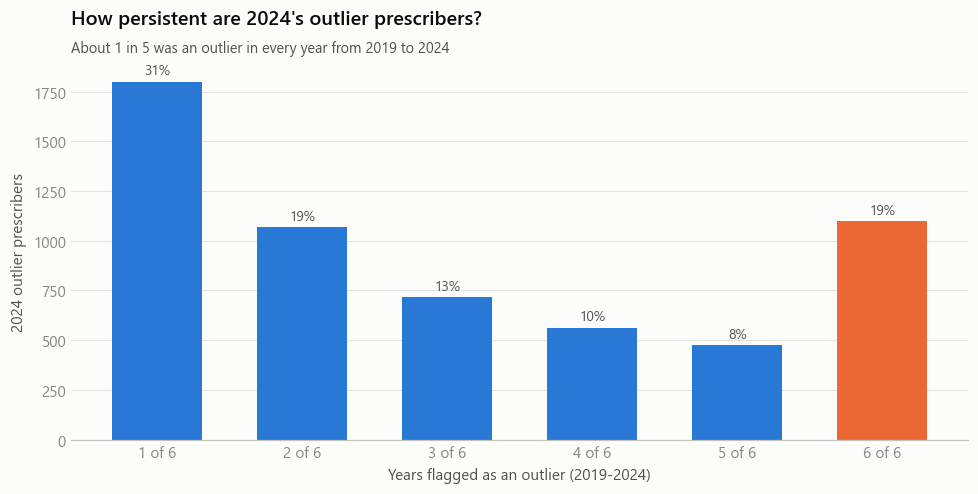

,data_year,eligible,outliers,outlier_claims,claims,outlier_share_of_claims
0,2019,598657,4701,3387931.0,63492826.0,5.3
1,2020,595652,4735,3500868.0,60514004.0,5.8
2,2021,621045,4882,3542351.0,58664970.0,6.0
3,2022,650506,5116,3679127.0,57350094.0,6.4
4,2023,692012,5484,3851167.0,56935075.0,6.8
5,2024,720013,5721,4139790.0,57906255.0,7.1


In [6]:
outliers = sql("""
    SELECT data_year, count(*) AS eligible, count(*) FILTER (WHERE is_high_outlier) AS outliers,
           sum(opioid_claims) FILTER (WHERE is_high_outlier) AS outlier_claims, sum(opioid_claims) AS claims
    FROM analytics.prescriber_benchmark GROUP BY data_year ORDER BY data_year""")
outliers["outlier_share_of_claims"] = (outliers["outlier_claims"] / outliers["claims"] * 100).round(1)
persist = sql("""
    WITH f AS (SELECT npi, count(*) FILTER (WHERE is_high_outlier) AS years_flagged,
                      bool_or(is_high_outlier AND data_year = 2024) AS flagged_2024
               FROM analytics.prescriber_benchmark GROUP BY npi)
    SELECT years_flagged, count(*) AS prescribers FROM f WHERE flagged_2024 GROUP BY 1 ORDER BY 1""")

fig, ax = plt.subplots()
bars = ax.bar(persist["years_flagged"], persist["prescribers"], width=0.62,
              color=[vs.ORANGE if y == 6 else vs.BLUE for y in persist["years_flagged"]])
share = persist["prescribers"] / persist["prescribers"].sum()
ax.bar_label(bars, labels=[f"{s:.0%}" for s in share], padding=3, color=vs.INK_2, fontsize=9)
ax.set_xticks(persist["years_flagged"], [f"{y} of 6" for y in persist["years_flagged"]])
ax.set_xlabel("Years flagged as an outlier (2019-2024)")
ax.set_ylabel("2024 outlier prescribers")
ax.set_title("How persistent are 2024's outlier prescribers?")
vs.subtitle(ax, "About 1 in 5 was an outlier in every year from 2019 to 2024")
vs.save(fig, "05_outlier_persistence")
plt.show()
outliers

## 5. Rural vs urban

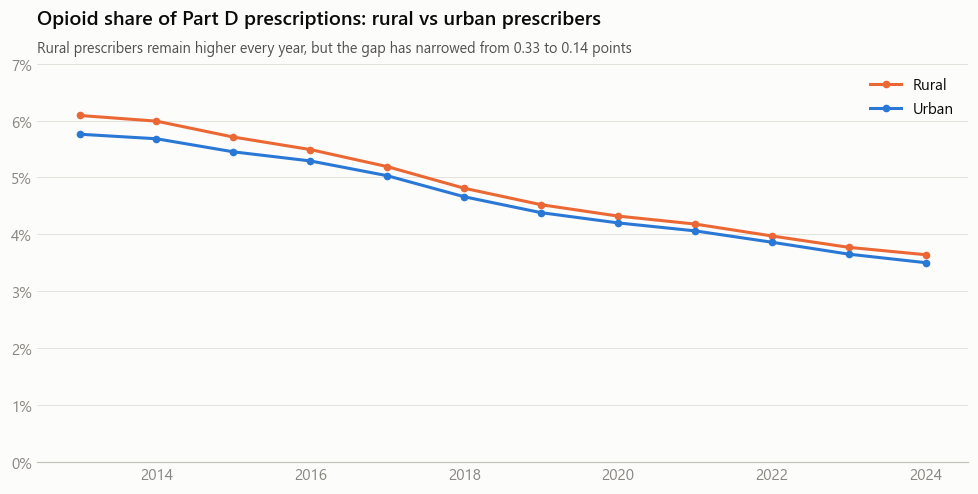

In [7]:
fig, ax = plt.subplots()
for area, color in [("Rural", vs.ORANGE), ("Urban", vs.BLUE)]:
    d = rural[rural["area"] == area]
    ax.plot(d["year"], d["opioid_rate"] / 100, color=color, marker="o", markersize=4, label=area)
ax.set_ylim(0, 0.07)
vs.pct(ax, decimals=0)
ax.legend(loc="upper right")
ax.set_title("Opioid share of Part D prescriptions: rural vs urban prescribers")
vs.subtitle(ax, "Rural prescribers remain higher every year, but the gap has narrowed from 0.33 to 0.14 points")
vs.save(fig, "06_rural_urban")
plt.show()

## 6. Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | The opioid share of Medicare prescriptions fell **40%** (5.8% to 3.5%) from 2013 to 2024, every single year. | Prescribing guidelines and monitoring programs are working on the prescribing side. |
| 2 | Over the same period overdose deaths **doubled** (52,600 in 2015 to 109,400 in 2022). By 2023, **92%** of opioid deaths involved synthetic opioids (mainly fentanyl), up from 29% in 2015. | The crisis moved from prescription pills to the illicit supply; cutting prescriptions further will not reverse it on its own. |
| 3 | Across states, prescribing rate correlates **negatively** with overdose deaths (r = -0.28 in 2019) and only weakly positively with prescription-opioid deaths. | Resource allocation should follow death data and illicit-supply indicators, not prescribing rates. |
| 4 | NPs and PAs now write **30.5%** of Medicare opioid prescriptions (up from 22.5% in 2019), while primary care physicians fell from 42.8% to 34.6%. | Prescriber education and monitoring programs need to target NPs and PAs, not just physicians. |
| 5 | About 1% of prescribers in each specialty are extreme peer outliers, and **1 in 5** of 2024's outliers was flagged in every year since 2019. | A persistent, identifiable group is a practical target for payer review and outreach. |

*Limitations:* Medicare Part D only (mostly adults 65+ and people with disabilities), not all US prescribing; prescriber
opioid counts of 1-10 are suppressed by CMS (these are 2.2% of claims, reconciled in `SQL/query_results.md`); 2024 CDC
counts are provisional; the state-level correlations are ecological and do not show individual-level causation.